# Import Libraries & Load Dataset

The statistical section begins by importing the necessary libraries required for data manipulation, numerical computation, statistical modelling, and visualisation.

In [163]:
# Imports
import pandas as pd
import numpy as np
from utils import engine

# Statistical distributions
import scipy.stats as stats
from scipy.stats import poisson, norm, binom

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plotting style
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

# load the dataset
df_stats= pd.read_sql("SELECT * FROM predict_df",engine)

# Descriptive Statistical Analysis
## Dataset Overview

In [139]:
df_stats.head()

,country,year,milk_prod_1000t,butter_prod_1000t,cheese_prod_1000t,milk_powder_prod_1000t,milk_delivered_to_dairies_1000t,milk_per_cow,dairy_cow_pop_1000,bovine_pop_1000,...,Butter of cow milk_Export value_1000 USD,Cheese from whole cow milk_Export value_1000 USD,Whole milk powder_Export value_1000 USD,total_dairy_export_value_1000USD,export_per_cow,output_per_labour,milk_prod_growth_pct,export_growth_pct,lag_export_value,dairy_cow_share
0,France,2016,26065.89,434.23,1918.97,516.27,24453.33,7.166826,3637.02,19559.30,...,334064.0,2917472.0,259515.0,3905696.0,1073.872566,93.617697,NaN,NaN,NaN,0.185948
1,France,2017,26006.31,412.72,1919.57,504.57,24629.49,7.230322,3596.84,19432.72,...,440864.0,3060918.0,295481.0,4184732.0,1163.446803,98.104203,-0.228575,7.144335,3905696.0,0.185092
2,France,2018,26022.50,417.41,1907.76,451.82,24542.54,7.321558,3554.23,18736.99,...,487249.0,3271157.0,274410.0,4417132.0,1242.781700,105.440560,0.062254,5.553522,4184732.0,0.189691
3,France,2019,26036.29,419.22,1903.29,470.06,24526.30,7.458524,3490.81,18469.77,...,453927.0,3117875.0,253199.0,4156105.0,1190.584707,105.851916,0.052993,-5.909423,4417132.0,0.189001
4,France,2020,26288.53,417.54,1862.10,486.48,24602.21,7.719025,3405.68,18200.48,...,439690.0,3150066.0,290181.0,4208091.0,1235.609629,104.625639,0.968802,1.250835,4156105.0,0.187120


In [140]:
df_stats.columns

Index(['country', 'year', 'milk_prod_1000t', 'butter_prod_1000t',
       'cheese_prod_1000t', 'milk_powder_prod_1000t',
       'milk_delivered_to_dairies_1000t', 'milk_per_cow', 'dairy_cow_pop_1000',
       'bovine_pop_1000', 'total_labour_awu',
       'agri_output_basic_price_million_eur',
       'cap_direct_payments_million_eur',
       'Raw milk of cattle_Export value_1000 USD',
       'Butter of cow milk_Export value_1000 USD',
       'Cheese from whole cow milk_Export value_1000 USD',
       'Whole milk powder_Export value_1000 USD',
       'total_dairy_export_value_1000USD', 'export_per_cow',
       'output_per_labour', 'milk_prod_growth_pct', 'export_growth_pct',
       'lag_export_value', 'dairy_cow_share'],
      dtype='object')

In [141]:
df_stats.shape

(54, 24)

In [142]:
df_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 24 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   country                                           54 non-null     object 
 1   year                                              54 non-null     int64  
 2   milk_prod_1000t                                   54 non-null     float64
 3   butter_prod_1000t                                 54 non-null     float64
 4   cheese_prod_1000t                                 54 non-null     float64
 5   milk_powder_prod_1000t                            49 non-null     float64
 6   milk_delivered_to_dairies_1000t                   54 non-null     float64
 7   milk_per_cow                                      54 non-null     float64
 8   dairy_cow_pop_1000                                54 non-null     float64
 9   bovine_pop_1000        

In [143]:
df_stats.duplicated().sum()


np.int64(0)

In [144]:
df_stats["country"].unique()

array(['France', 'Germany', 'Ireland', 'Italy', 'Netherlands', 'Poland'],
      dtype=object)

In [145]:
df_stats.describe()

,year,milk_prod_1000t,butter_prod_1000t,cheese_prod_1000t,milk_powder_prod_1000t,milk_delivered_to_dairies_1000t,milk_per_cow,dairy_cow_pop_1000,bovine_pop_1000,total_labour_awu,...,Butter of cow milk_Export value_1000 USD,Cheese from whole cow milk_Export value_1000 USD,Whole milk powder_Export value_1000 USD,total_dairy_export_value_1000USD,export_per_cow,output_per_labour,milk_prod_growth_pct,export_growth_pct,lag_export_value,dairy_cow_share
count,54.000000,54.000000,54.000000,54.000000,49.000000,54.000000,54.000000,54.000000,54.000000,54.000000,...,5.400000e+01,5.400000e+01,54.000000,5.400000e+01,54.000000,54.000000,48.000000,48.000000,4.800000e+01,54.000000
mean,2020.000000,18356.863704,288.693889,1277.370556,409.793061,17204.431296,7.539752,2394.014630,8872.865370,682.827037,...,6.894388e+05,3.089707e+06,252962.388889,4.360990e+06,2010.438566,102.148167,1.131172,9.068097,4.198153e+06,0.297799
std,2.606233,8489.043457,129.445095,684.904753,198.256601,8395.399297,1.227674,952.322575,4824.223516,507.060166,...,5.023788e+05,1.721074e+06,219735.057520,2.104118e+06,1226.437796,68.962151,2.500013,11.196871,2.005665e+06,0.082999
min,2016.000000,6871.940000,91.220000,206.100000,25.760000,6851.630000,5.305575,1295.230000,3693.000000,152.020000,...,3.265900e+04,5.433500e+05,8611.000000,9.192460e+05,431.591155,11.566522,-4.145349,-8.083827,9.192460e+05,0.179365
25%,2018.000000,13352.452500,215.110000,894.335000,201.350000,11913.085000,6.477261,1569.250000,6094.195000,160.780000,...,3.179758e+05,1.139486e+06,64015.000000,2.565638e+06,1201.840937,51.189757,-0.255918,2.063810,2.498198e+06,0.200350
50%,2020.000000,14827.935000,257.780000,1128.165000,439.670000,13564.525000,7.540542,2036.240000,6813.610000,589.890000,...,6.145910e+05,3.342566e+06,222587.500000,4.263066e+06,1726.967800,87.972860,0.831668,6.522370,4.196412e+06,0.317049
75%,2022.000000,25962.002500,412.727500,1907.587500,522.700000,24389.870000,8.260635,3384.767500,11361.655000,1059.950000,...,1.081164e+06,4.165329e+06,337700.750000,5.930207e+06,2350.134379,133.884759,2.500173,13.200424,5.912342e+06,0.345897
max,2024.000000,34033.750000,506.930000,2433.320000,725.010000,32548.980000,9.740367,4217.700000,19559.300000,1937.100000,...,1.773153e+06,6.195032e+06,798904.000000,8.625234e+06,5648.483301,263.714376,9.124061,46.272293,8.255649e+06,0.424003


In [146]:
df_stats.describe(include= "all")

,country,year,milk_prod_1000t,butter_prod_1000t,cheese_prod_1000t,milk_powder_prod_1000t,milk_delivered_to_dairies_1000t,milk_per_cow,dairy_cow_pop_1000,bovine_pop_1000,...,Butter of cow milk_Export value_1000 USD,Cheese from whole cow milk_Export value_1000 USD,Whole milk powder_Export value_1000 USD,total_dairy_export_value_1000USD,export_per_cow,output_per_labour,milk_prod_growth_pct,export_growth_pct,lag_export_value,dairy_cow_share
count,54,54.000000,54.000000,54.000000,54.000000,49.000000,54.000000,54.000000,54.000000,54.000000,...,5.400000e+01,5.400000e+01,54.000000,5.400000e+01,54.000000,54.000000,48.000000,48.000000,4.800000e+01,54.000000
unique,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2020.000000,18356.863704,288.693889,1277.370556,409.793061,17204.431296,7.539752,2394.014630,8872.865370,...,6.894388e+05,3.089707e+06,252962.388889,4.360990e+06,2010.438566,102.148167,1.131172,9.068097,4.198153e+06,0.297799
std,NaN,2.606233,8489.043457,129.445095,684.904753,198.256601,8395.399297,1.227674,952.322575,4824.223516,...,5.023788e+05,1.721074e+06,219735.057520,2.104118e+06,1226.437796,68.962151,2.500013,11.196871,2.005665e+06,0.082999
min,NaN,2016.000000,6871.940000,91.220000,206.100000,25.760000,6851.630000,5.305575,1295.230000,3693.000000,...,3.265900e+04,5.433500e+05,8611.000000,9.192460e+05,431.591155,11.566522,-4.145349,-8.083827,9.192460e+05,0.179365
25%,NaN,2018.000000,13352.452500,215.110000,894.335000,201.350000,11913.085000,6.477261,1569.250000,6094.195000,...,3.179758e+05,1.139486e+06,64015.000000,2.565638e+06,1201.840937,51.189757,-0.255918,2.063810,2.498198e+06,0.200350
50%,NaN,2020.000000,14827.935000,257.780000,1128.165000,439.670000,13564.525000,7.540542,2036.240000,6813.610000,...,6.145910e+05,3.342566e+06,222587.500000,4.263066e+06,1726.967800,87.972860,0.831668,6.522370,4.196412e+06,0.317049
75%,NaN,2022.000000,25962.002500,412.727500,1907.587500,522.700000,24389.870000,8.260635,3384.767500,11361.655000,...,1.081164e+06,4.165329e+06,337700.750000,5.930207e+06,2350.134379,133.884759,2.500173,13.200424,5.912342e+06,0.345897


### Observation

The dataset contains 54 observations and 24 variables, covering six selected EU countries from 2016 to 2024. The dataset is mainly numerical, with 22 float columns, one integer year column, and one categorical country column. There are no duplicate rows, which suggests that each country-year record is represented only once. Some missing values are present but these are expected because growth and lag features cannot be calculated for the first available year of each country. 

The describe() output shows that dairy production, export value and CAP payment variables have wide ranges across the selected countries. This is expected too because the comparison includes countries with different dairy sector sizes and agricultural structures. It also gives an early reason to check variation, skewness and possible scaling needs before modelling.

## Measures of Central Tendency

Based on the problem domain identified the target feature will be "total_dairy_export_value_1000USD" for the Ireland, therefore the further statiscal analysis will be carried out using the features deemed relevant to the analysis.

In [147]:
df_stats_ie = df_stats[df_stats["country"]=="Ireland"]

key_numeric_cols = [
    "total_dairy_export_value_1000USD",
    "milk_prod_1000t",
    "milk_delivered_to_dairies_1000t",
    "butter_prod_1000t",
    "cheese_prod_1000t",
    "milk_powder_prod_1000t",
    "milk_per_cow",
    "output_per_labour",
    "export_per_cow",
    "agri_output_basic_price_million_eur",
    "cap_direct_payments_million_eur",
    "lag_export_value",
    "milk_prod_growth_pct"
]

# Compute central tendency measures
central_tendency = pd.DataFrame({
    "mean": df_stats_ie[key_numeric_cols].mean(),
    "median": df_stats_ie[key_numeric_cols].median(),
    "mode": df_stats_ie[key_numeric_cols].mode().iloc[0]
}).round(2)

central_tendency

,mean,median,mode
total_dairy_export_value_1000USD,2620637.44,2506868.00,1426413.00
milk_prod_1000t,8287.18,8561.47,6871.94
milk_delivered_to_dairies_1000t,8266.61,8542.27,6851.63
butter_prod_1000t,282.22,293.90,299.30
cheese_prod_1000t,260.08,278.40,206.10
milk_powder_prod_1000t,499.29,516.20,528.40
milk_per_cow,5.77,5.78,5.31
output_per_labour,61.68,56.91,46.32
export_per_cow,1812.97,1734.45,1101.28
agri_output_basic_price_million_eur,9891.03,8930.90,7444.21


### Observation
The results show that Ireland’s dairy export value's mean is slightly higher than the median. This suggests that higher export-value years pull the average upward, so the median is useful as a more stable middle-point measure. Milk production and milk delivered to dairies have median values slightly above their means, suggesting that lower values in some years reduce the overall average. This supports the need to look at trends over time rather than relying only on one summary value.

Productivity-related variables such as "milk_per_cow", "output_per_labour" and "export_per_cow" show that dairy sector is not only important in production scale, but also in efficiency terms. These variables should therefore be carried forward into  further analysis.

The mode is reported as part of central tendency, but it is less useful for this dataset because most variables are continuous yearly measurements with limited repeated values. Therefore, the mean and median are important here in this case.



## Measures of Dispersion

In [148]:
# Compute dispersion measures 
dispersion = pd.DataFrame({
    "min": df_stats_ie[key_numeric_cols].min(),
    "max": df_stats_ie[key_numeric_cols].max(),
    "range": df_stats_ie[key_numeric_cols].max() - df_stats_ie[key_numeric_cols].min(),
    "variance": df_stats_ie[key_numeric_cols].var(),
    "std_dev": df_stats_ie[key_numeric_cols].std(),
    "iqr": df_stats_ie[key_numeric_cols].quantile(0.75) - df_stats_ie[key_numeric_cols].quantile(0.25),
    "coefficient_of_variation": df_stats_ie[key_numeric_cols].std() / df_stats_ie[key_numeric_cols].mean()
}).round(2)

dispersion

,min,max,range,variance,std_dev,iqr,coefficient_of_variation
total_dairy_export_value_1000USD,1426413.00,3485834.00,2059421.00,4.213812e+11,649138.83,725632.00,0.25
milk_prod_1000t,6871.94,9108.28,2236.34,5.643609e+05,751.24,899.46,0.09
milk_delivered_to_dairies_1000t,6851.63,9086.73,2235.10,5.647145e+05,751.47,899.32,0.09
butter_prod_1000t,229.80,305.90,76.10,6.353100e+02,25.21,29.00,0.09
cheese_prod_1000t,206.10,286.90,80.80,1.083670e+03,32.92,59.50,0.13
milk_powder_prod_1000t,393.30,600.90,207.60,3.573280e+03,59.78,65.40,0.12
milk_per_cow,5.31,6.03,0.73,5.000000e-02,0.22,0.16,0.04
output_per_labour,46.32,82.33,36.00,1.348500e+02,11.61,14.57,0.19
export_per_cow,1101.28,2353.21,1251.93,1.400976e+05,374.30,330.30,0.21
agri_output_basic_price_million_eur,7444.21,12920.56,5476.35,3.805839e+06,1950.86,2911.26,0.20


### Observation

Ireland’s total dairy export value shows a wide range, moving from about **1.43** to **3.49**. Milk production and milk delivered to dairies show moderate variation, while milk_per_cow has a very low coefficient of variation. This suggests that Ireland’s milk yield per cow was relatively stable compared with export value, output per labour and export per cow.

Export_per_cow and output_per_labour show stronger variation, which means efficiency-related indicators changed more than basic milk yield. 

CAP direct payments have the lowest coefficient of variation, showing it was relatively stable during the period. In contrast, milk_prod_growth_pct has the highest coefficient of variation, but this should be interpreted carefully because growth rates naturally fluctuate and can be sensitive when the average growth rate is small.


## Distribution and Shape Analysis

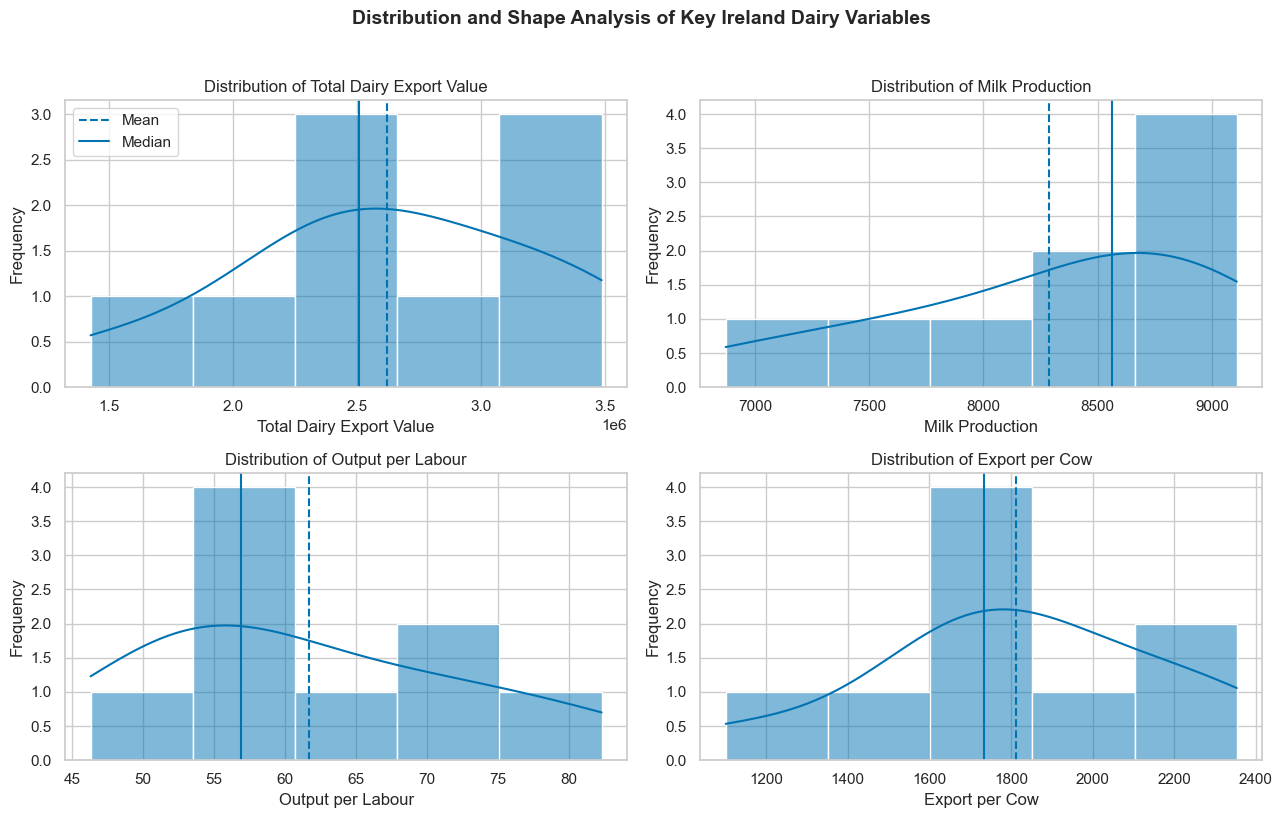

In [149]:
# Key variables for distribution analysis
selected_features = ["total_dairy_export_value_1000USD","milk_prod_1000t","output_per_labour","export_per_cow"]

# More readable labels for plots
feature_labels = {
    "total_dairy_export_value_1000USD": "Total Dairy Export Value",
    "milk_prod_1000t": "Milk Production",
    "output_per_labour": "Output per Labour",
    "export_per_cow": "Export per Cow"
}

# Plot histograms 
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, selected_features)):
    
    sns.histplot(data=df_stats_ie,x=col,kde=True,bins=5,ax=ax)
    
    ax.axvline(df_stats_ie[col].mean(),linestyle="--",linewidth=1.5,label="Mean")
    ax.axvline(df_stats_ie[col].median(),linestyle="-",linewidth=1.5,label="Median")
    
    ax.set_title(f"Distribution of {feature_labels[col]}")
    ax.set_xlabel(feature_labels[col])
    ax.set_ylabel("Frequency")
    
    # Show legend only once to avoid repetition
    if i == 0:
        ax.legend(frameon=True)
    else:
        ax.legend().remove()

fig.suptitle("Distribution and Shape Analysis of Key Ireland Dairy Variables",fontsize=14,fontweight="semibold",y=1.02)
plt.tight_layout()


### Observation
The distribution plots show mild departures from normality, but no variable appears severely skewed. Total dairy export value and output per labour show slight right-skewness, while milk production is concentrated toward the higher end of its range(the shape looks exaggerated because the observations are limited). 

Export per cow is relatively more centred, although it still varies across years. Because the skewness is not extreme and the Ireland subset has only nine yearly observations, log transformation is not deemed useful. However, scaling should be considered in later modelling because the variables are measured in very different units.

## Outlier Detection & Analysis

The selected variables are standardised using z-scores only for visual comparison, because they are measured in very different units.

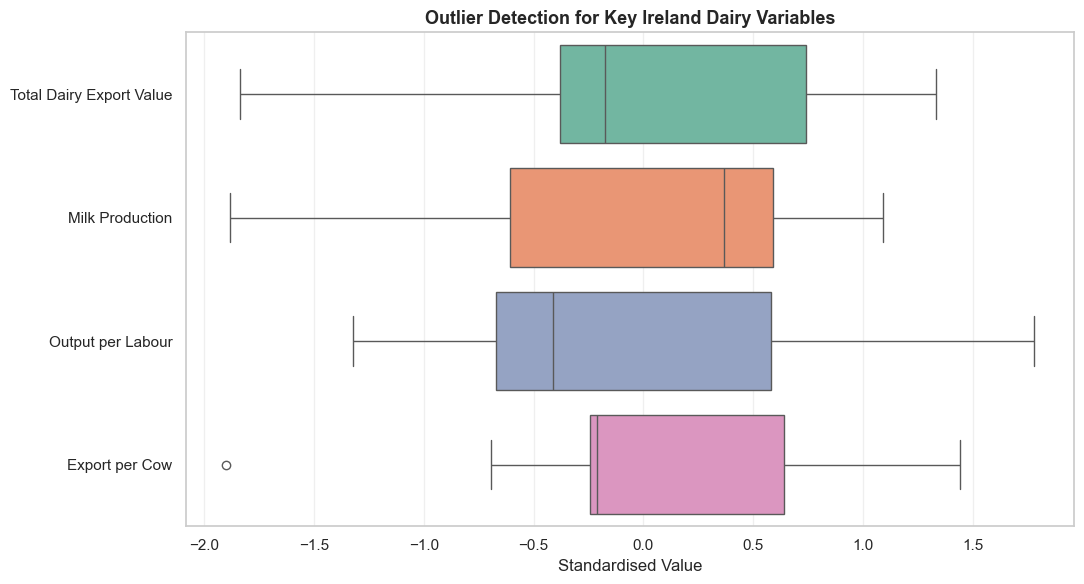

In [150]:
# Create a copy of the selected Ireland variables
scaled_features = df_stats_ie[selected_features].copy()

# Standardise the variables using z-score scaling
scaled_features = (scaled_features - scaled_features.mean()) / scaled_features.std()

# Rename columns for clearer labels
scaled_features = scaled_features.rename(columns=feature_labels)

# Convert to long format for plotting
scaled_long = scaled_features.melt(var_name="Variable", value_name="Standardised Value")

# Plot boxplots 
plt.figure(figsize=(11, 6))

sns.boxplot(data=scaled_long,y="Variable",x="Standardised Value",hue="Variable",palette="Set2",legend=False)

plt.title("Outlier Detection for Key Ireland Dairy Variables",fontsize=13,fontweight="semibold")
plt.xlabel("Standardised Value")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

### Observation
The boxplots show that most variables do not have severe outliers. Export value, milk production and output per labour vary across the years, but their values remain within the expected spread. Export per Cow has one low-end outlier, suggesting one year of weaker export efficiency. This should be kept for analysis unless proven to be a data error, as it may reflect a real yearly drop.


## Country-Level Descriptive Context

Lets see how Ireland compares descriptively against top EU dairy countries: France, Germany, Italy, Netherlands and Poland.

In [151]:
# Key variables for compact country-level comparison
comparison_cols = [
    "total_dairy_export_value_1000USD",
    "milk_prod_1000t",
    "milk_per_cow",
    "output_per_labour",
    "export_per_cow",
    "cap_direct_payments_million_eur"
]

# Country-level summary
country_summary = (
    df_stats
    .groupby("country")
    .agg(
        avg_export_value=("total_dairy_export_value_1000USD", "mean"),
        median_export_value=("total_dairy_export_value_1000USD", "median"),
        avg_milk_production=("milk_prod_1000t", "mean"),
        avg_milk_per_cow=("milk_per_cow", "mean"),
        avg_output_per_labour=("output_per_labour", "mean"),
        avg_export_per_cow=("export_per_cow", "mean"),
        avg_cap_payments=("cap_direct_payments_million_eur", "mean")
    )
    .round(2)
    .reset_index()
)

country_summary

,country,avg_export_value,median_export_value,avg_milk_production,avg_milk_per_cow,avg_output_per_labour,avg_export_per_cow,avg_cap_payments
0,France,4506549.44,4417132.0,25802.80,7.64,113.34,1342.05,6974.92
1,Germany,6588926.78,5936102.0,33053.61,8.43,137.48,1693.93,4679.09
2,Ireland,2620637.44,2506868.0,8287.18,5.77,61.68,1812.97,1191.39
3,Italy,4114443.22,3655169.0,13486.59,7.14,57.96,2198.54,3606.38
4,Netherlands,6760751.11,6274304.0,14830.39,9.31,222.63,4267.44,662.66
5,Poland,1574630.44,1427198.0,14680.61,6.95,19.79,747.71,3364.44


### Observation
Ireland sits in the middle for average dairy export value. Its average milk production is lower than the larger dairy producers, but its average export per cow is stronger than France, Germany and Poland. 

These descriptive differences show why country structure needs to be considered in later analysis. Formal statistical comparison is left for the inferential testing section.


## Trend & Relatiosnhip Analysis

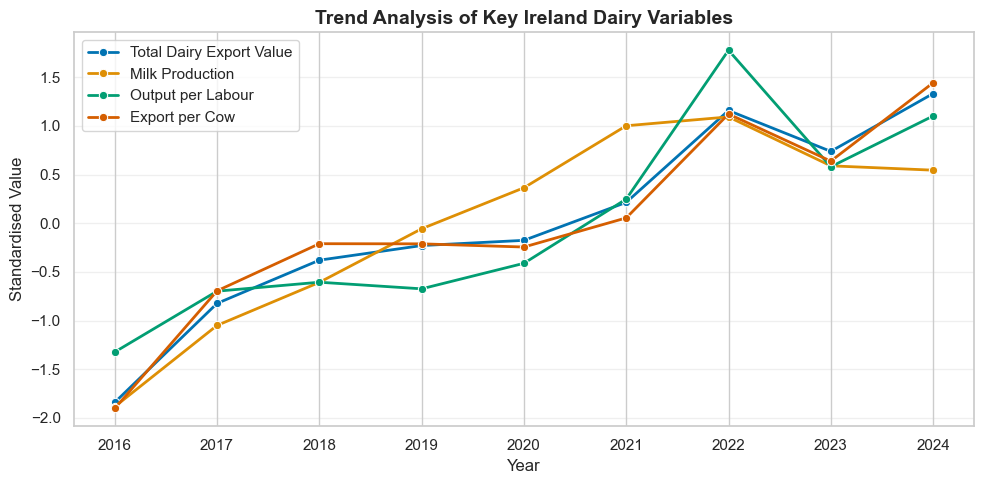

In [152]:
# Create trend dataset using the same selected features
trend_df = df_stats_ie[["year"] + selected_features].copy()

# Standardise selected variables for comparison on one plot
trend_scaled = trend_df.copy()
trend_scaled[selected_features] = (
    trend_scaled[selected_features] - trend_scaled[selected_features].mean()
) / trend_scaled[selected_features].std()

# Rename columns for clearer labels
trend_scaled = trend_scaled.rename(columns=feature_labels)

# Convert to long format
trend_long = trend_scaled.melt(
    id_vars="year",
    var_name="Variable",
    value_name="Standardised Value"
)

# Plot trend analysis
plt.figure(figsize=(10, 5))

sns.lineplot(data=trend_long,x="year",y="Standardised Value",hue="Variable",marker="o",linewidth=2)

plt.title("Trend Analysis of Key Ireland Dairy Variables", fontsize=14, fontweight="semibold")
plt.xlabel("Year")
plt.ylabel("Standardised Value")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="")
plt.tight_layout()


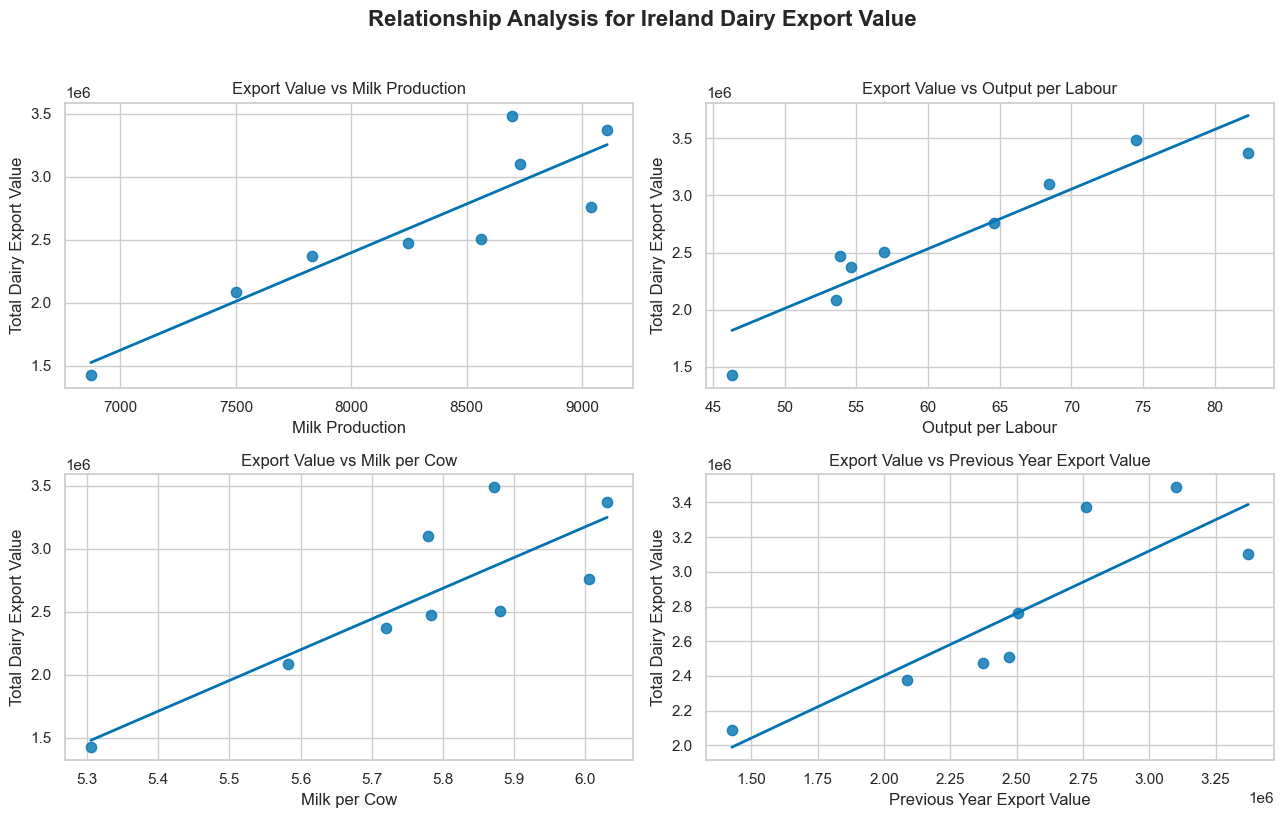

In [153]:
# Variables used to examine relationships with export value
relationship_features = [
    "milk_prod_1000t",
    "output_per_labour",
    "milk_per_cow",
    "lag_export_value"
]

relationship_labels = {
    "milk_prod_1000t": "Milk Production",
    "output_per_labour": "Output per Labour",
    "milk_per_cow": "Milk per Cow",
    "lag_export_value": "Previous Year Export Value"
}

# Plot relationship 
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, relationship_features):
    
    sns.regplot(
        data=df_stats_ie,
        x=col,
        y="total_dairy_export_value_1000USD",
        ax=ax,
        ci=None,
        scatter_kws={"s": 55},
        line_kws={"linewidth": 2}
    )
    
    ax.set_title(f"Export Value vs {relationship_labels[col]}")
    ax.set_xlabel(relationship_labels[col])
    ax.set_ylabel("Total Dairy Export Value")

fig.suptitle("Relationship Analysis for Ireland Dairy Export Value",fontsize=16,fontweight="semibold",y=1.02)
plt.tight_layout()


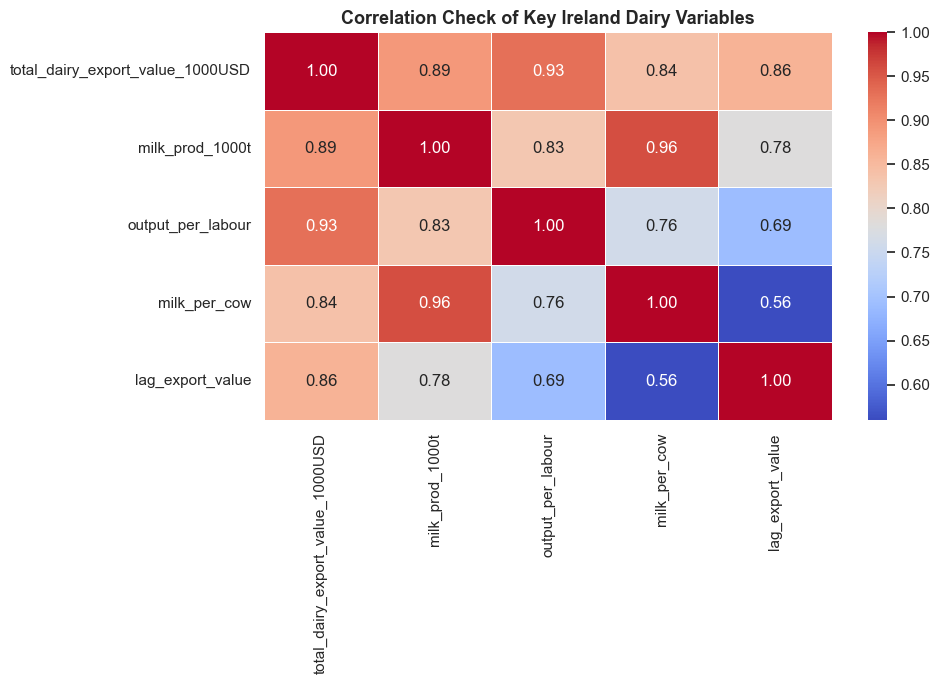

In [154]:
# Correlation check for variables linked to Ireland dairy export value
corr_cols = [
    "total_dairy_export_value_1000USD",
    "milk_prod_1000t",
    "output_per_labour",
    "milk_per_cow",
    "lag_export_value"
]

# Pearson correlation is used here to check linear relationships for model justification
corr_matrix = df_stats_ie[corr_cols].corr(method="pearson").round(2)

plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)

plt.title("Correlation Check of Key Ireland Dairy Variables",fontsize=13,fontweight="semibold")
plt.tight_layout()


# Observations: Trend, Relationship and Model Justification

The trend plot shows that Ireland’s dairy export value, milk production, output per labour and export per cow generally moved upward over time, with a dip around 2023 and recovery in 2024. This supports the use of time-aware analysis because export performance is not static across the period.

The relationship plots show positive associations between dairy export value and milk production, output per labour, milk per cow and previous-year export value. This suggests that Ireland’s export performance is linked not only to production scale, but also to productivity, dairy efficiency and historical export behaviour.

The correlation heatmap supports the visual findings, with strong positive correlations between export value and output per labour, milk production, milk per cow and lagged export value. These results help justify testing linear regression models, while the different variable scales and strong relationships between predictors also support scaling and regularised models such as Ridge or Lasso. Since the relationships are strong but based on a small yearly dataset, more flexible models can also be tested, but the results should be interpreted carefully rather than treated as causal proof since the dataset is limited.


# Inferential Statistics

In [155]:
# Ireland 2016-2024 is treated as the population frame
# Variables considered for inferential statistics
sample_vars = [
    "total_dairy_export_value_1000USD",
    "output_per_labour",
    "export_per_cow"
]

sample_labels = {
    "total_dairy_export_value_1000USD": "Total Dairy Export Value",
    "output_per_labour": "Output per Labour",
    "export_per_cow": "Export per Cow"
}

# Different sample sizes drawn from the 9 Ireland observations
sample_sizes = [3, 4, 5]

# Store samples
samples = {}

for var in sample_vars:
    samples[var] = {}
    
    for n in sample_sizes:
        samples[var][n] = df_stats_ie[var].dropna().sample(n=n,random_state=42)

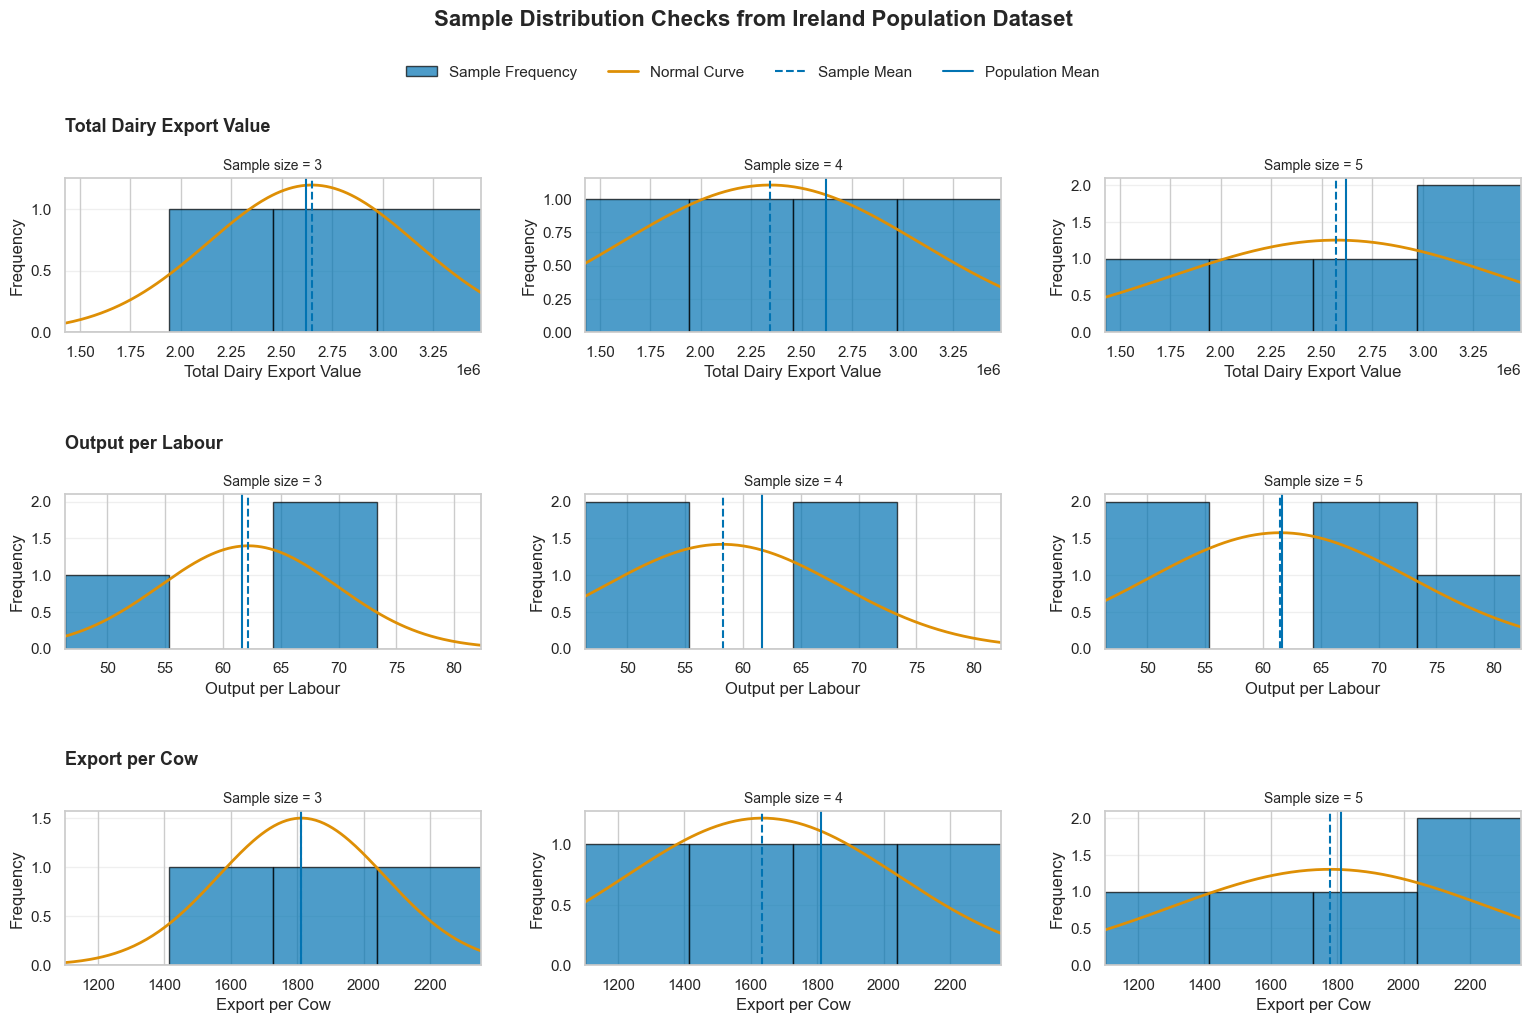

In [156]:
# Lets now visualize the different sample sizes taken

fig, axes = plt.subplots(len(sample_vars),len(sample_sizes),figsize=(16, 10.5),squeeze=False)

for i, var in enumerate(sample_vars):
    population_data = df_stats_ie[var].dropna()

    # Keep same x-axis range and bins for all samples of the same variable
    x_min = population_data.min()
    x_max = population_data.max()
    bins = np.linspace(x_min, x_max, 5)

    for j, n in enumerate(sample_sizes):
        sample_data = samples[var][n].dropna()
        ax = axes[i, j]

        # Histogram showing sample frequency
        counts, bin_edges, patches = ax.hist(
            sample_data,
            bins=bins,
            alpha=0.70,
            edgecolor="black",
            label="Sample Frequency"
        )

        # Sample statistics
        sample_mean = sample_data.mean()
        sample_std = sample_data.std()
        population_mean = population_data.mean()

        # Normal curve based on sample mean and standard deviation
        if sample_std > 0:
            x = np.linspace(x_min, x_max, 200)
            bin_width = bin_edges[1] - bin_edges[0]
            normal_curve = stats.norm.pdf(x, sample_mean, sample_std) * len(sample_data) * bin_width

            ax.plot(x,normal_curve,linewidth=2,label="Normal Curve")

        # Sample mean and population mean reference lines
        ax.axvline(sample_mean,linestyle="--",linewidth=1.5,label="Sample Mean")
        ax.axvline(population_mean,linestyle="-",linewidth=1.5,label="Population Mean")

        ax.set_title(f"Sample size = {n}", fontsize=10, pad=6)
        ax.set_xlabel(sample_labels[var])
        ax.set_ylabel("Frequency")
        ax.set_xlim(x_min, x_max)
        ax.grid(axis="y", alpha=0.3)

# Create enough space for title, legend, and row headings
fig.subplots_adjust(left=0.07,right=0.98,bottom=0.07,top=0.82,wspace=0.25,hspace=1.05)

# Add variable headings above each row, aligned to the left
for i, var in enumerate(sample_vars):
    row_top = max(axes[i, j].get_position().y1 for j in range(len(sample_sizes)))
    row_left = min(axes[i, j].get_position().x0 for j in range(len(sample_sizes)))

    fig.text(row_left,row_top + 0.04,sample_labels[var],fontsize=13,fontweight="semibold",ha="left",va="bottom")


fig.suptitle("Sample Distribution Checks from Ireland Population Dataset",fontsize=16,fontweight="semibold",y=0.98)

# One shared legend
legend_handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(legend_handles,legend_labels,loc="upper center",bbox_to_anchor=(0.5, 0.94),ncol=4,frameon=False)

Sample size 4 can be selected because it provides a reasonable balance within the small Ireland population frame of nine observations and a good visual normality guide. A sample of 3 is too unstable and can be strongly affected by one yearly value, while a sample of 5 uses more than half of the population and becomes closer to a near-population summary. 

In [157]:
# Calculating inferential stats and confidence interval

inferential_results = []

for var in sample_vars:
    
    # Selected sample for each variable
    sample_data = samples[var][selected_n].dropna()
    
    # Basic sample statistics
    n = len(sample_data)
    sample_mean = np.mean(sample_data)
    sample_std = np.std(sample_data, ddof=1)
    standard_error = stats.sem(sample_data)
    
    # 95% confidence interval using t-distribution
    ci_lower, ci_upper = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=sample_mean,
        scale=standard_error
    )
    
    inferential_results.append({
        "Variable": sample_labels[var],
        "Sample Size": n,
        "Sample Mean": sample_mean,
        "Sample Std Dev": sample_std,
        "Standard Error": standard_error,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper
    })

inferential_results_df = pd.DataFrame(inferential_results).round(2)

inferential_results_df

,Variable,Sample Size,Sample Mean,Sample Std Dev,Standard Error,95% CI Lower,95% CI Upper
0,Total Dairy Export Value,4,2343319.00,742387.90,371193.95,1162014.18,3524623.82
1,Output per Labour,4,58.22,10.12,5.06,42.11,74.34
2,Export per Cow,4,1635.04,410.24,205.12,982.26,2287.82


### Interpretation 

We are 95% confident that the true population mean for each selected variable lies between the lower and upper confidence interval limits shown in table above.
- Ireland’s mean dairy export value is estimated to lie between 1,162,014.18 and 3,524,623.82 thousand USD.
- Ireland’s mean output per labour is estimated to lie between 42.11 and 74.34.
- Ireland’s mean export per cow is estimated to lie between 982.26 and 2,287.82.

########### Hypothesis Testings

### Before applying inferential statistical tests, the dataset will be reviewed to identify suitable comparator countries for Ireland.
Three variables used earlier are selected for comparison because they represent export scale, productivity, and export efficiency. 

Since each country has only a small number of yearly observations, the suitability of each test will be checked carefully. A Z-test is not used because the sample size per country is below 30. Instead, the analysis will use Shapiro-Wilk to check normality, followed by t-tests or Mann-Whitney tests for two-country comparisons, and ANOVA-based tests for wider country comparisons.

In [164]:
# Checking data coverage for each country
df_stats.groupby("country")["year"].agg(["min", "max", "nunique"])

,min,max,nunique
country,,,
France,2016,2024,9
Germany,2016,2024,9
Ireland,2016,2024,9
Italy,2016,2024,9
Netherlands,2016,2024,9
Poland,2016,2024,9


In [165]:
# Average values by country for selected comparison variables
country_avg = df_stats.groupby("country")[sample_vars].mean().round(2)

country_avg

,total_dairy_export_value_1000USD,output_per_labour,export_per_cow
country,,,
France,4506549.44,113.34,1342.05
Germany,6588926.78,137.48,1693.93
Ireland,2620637.44,61.68,1812.97
Italy,4114443.22,57.96,2198.54
Netherlands,6760751.11,222.63,4267.44
Poland,1574630.44,19.79,747.71
